### Import libraries

In [1]:
!pip install torchcodec soundfile librosa

In [2]:
from datasets import load_dataset, Audio
from huggingface_hub import login
from collections import Counter
from math import log2
from tqdm import tqdm

import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Import and analyze dataset

In [3]:
ds = load_dataset("AudioLLMs/spoken_squad_test")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

In [ ]:
ds

DatasetDict({
    test: Dataset({
        features: ['context', 'instruction', 'answer'],
        num_rows: 5351
    })
})

In [ ]:
ds['test'].features

{'context': Audio(sampling_rate=None, decode=True, stream_index=None),
 'instruction': Value('string'),
 'answer': Value('string')}

In [4]:
# Audio decoding not needed when analyzing text fields
test_ds = ds['test'].cast_column("context", Audio(decode=False))

In [ ]:
len(test_ds)

5351

### Common functions for data analysis and cleaning

In [5]:
def is_missing(x):
    return x is None or str(x).strip() == ""

In [6]:
def find_outliers(lengths):
    q1, q3 = np.percentile(lengths, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return [l for l in lengths if l < lower or l > upper]

In [7]:
def plot_histogram(lengths, length_title="Length"):
    plt.hist(lengths, bins=50)
    plt.xlabel(length_title)
    plt.ylabel("Frequency")
    plt.show()

In [8]:
def unique_ratio(lengths):
    return len(set(lengths)) / len(lengths)

In [9]:
def scatter_plot(x, y):
    plt.scatter(x, y, alpha=0.3)
    plt.xlabel("Instruction tokens")
    plt.ylabel("Answer tokens")
    plt.show()

In [10]:
def dominance_ratio(answers):
    counts = Counter(answers)
    most_common_freq = counts.most_common(1)[0][1]
    return most_common_freq / len(answers)

In [11]:
def entropy(answers):
    counts = Counter(answers)
    total = sum(counts.values())
    return -sum(
        (freq / total) * log2(freq / total)
        for freq in counts.values()
    )

In [12]:
def duration(audio):
    return len(audio["array"]) / audio["sampling_rate"]

In [13]:
def estimate_snr(audio):
    y = audio["array"]
    signal_power = np.mean(y ** 2)
    noise_power = np.mean((y - np.mean(y)) ** 2)
    return 10 * np.log10(signal_power / (noise_power + 1e-9))

### Analysis of text fields

In [ ]:
# Zero indicates no entries with missing questions or answers
missing_instructions = sum(is_missing(x["instruction"]) for x in test_ds)
missing_answers   = sum(is_missing(x["answer"]) for x in test_ds)

missing_instructions, missing_answers

(0, 0)

In [ ]:
# Calculate token lengths for questions and answers
tokens_instructions = [len(x["instruction"].split()) for x in test_ds]
tokens_answers  = [len(x["answer"].split()) for x in test_ds]

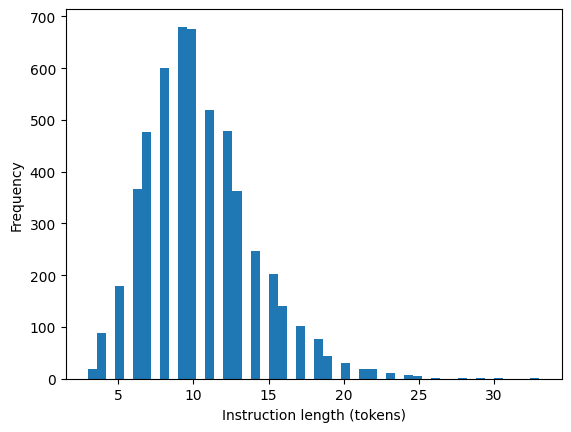

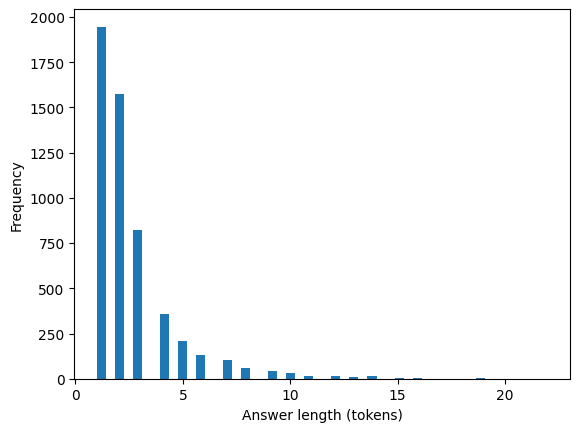

In [ ]:
# Identify token length distribution for questions and answers
plot_histogram(tokens_instructions, "Instruction length (tokens)")
print()
plot_histogram(tokens_answers, "Answer length (tokens)")

In [ ]:
# Most questions are of range 10-12 tokens
# Smallest question is 3 tokens
# Largest question is 33 tokens
pd.Series(tokens_instructions).describe()

,0
count,5351.000000
mean,10.364605
std,3.581564
min,3.000000
25%,8.000000
50%,10.000000
75%,12.000000
max,33.000000


In [ ]:
# Most answers are of range 2-3 tokens
# Smallest answer is 1 token (yes/no/digit)
# Largest answer is 22 tokens
pd.Series(tokens_answers).describe()

,0
count,5351.000000
mean,2.554663
std,2.138030
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,22.000000


In [ ]:
# Outliers calculated Q3 (75%) - Q1 (25%)
# Question outliers = 141/5351 = ~3%
# Answer outliers = 312/5351 = ~6%
outliers_instructions = find_outliers(tokens_instructions)
outliers_answers = find_outliers(tokens_answers)

len(outliers_instructions), len(outliers_answers)

(141, 312)

In [ ]:
# Presence of duplicates can be seen
instructions = [x["instruction"] for x in test_ds]
Counter(instructions).most_common(20)

[('How often do Parliament elections take place?', 2),
 ('What is needed to pack electrons densely together?', 2),
 ('What are the three sources of European Union law?', 2),
 ('What does the immune system protect against?', 2),
 ('What are two of its subsystems?', 2),
 ('Who won Super Bowl XLIX?', 2),
 ('Where did Maududi exert the most impact?', 2),
 ('Under what treaty can the European Commission take action against member states?',
  2),
 ('What did the non-Afghan veterans returning home have in addition to their prestige?',
  2),
 ('What is one problem with internet pharmacies?', 2),
 ('What was the theme of Super Bowl 50?', 2),
 ('Who won Super Bowl 50?', 2),
 ('What city did Super Bowl 50 take place in?', 2),
 ('Where did the Broncos practice for the Super Bowl?', 2),
 ('What did Luther think was required to stop the violence?', 1),
 ('What did Luther do during Lent at this time?', 1),
 ('How did Luther want people to bring about change?', 1),
 ('What troops attacked Fort William

In [ ]:
unique_instructions_ratio = unique_ratio(instructions)
unique_instructions_ratio

0.997383666604373

In [ ]:
# To check whether these are actual duplicates or not, we need to consider question-answer pairs
answers = [x["answer"] for x in test_ds]
Counter(answers).most_common(100)

[('three', 44),
 ('two', 31),
 ('four', 28),
 ('seven', 18),
 ('five', 17),
 ('six', 17),
 ('ten', 15),
 ('eight', 13),
 ('one', 12),
 ('nine', 12),
 ('miller', 12),
 ('new england patriots', 10),
 ('british', 9),
 ('oxygen', 9),
 ('peyton manning', 9),
 ('germany', 8),
 ('water', 8),
 ('third', 8),
 ('newton', 8),
 ('arizona cardinals', 8),
 ('linebacker', 7),
 ('second', 7),
 ('gold', 7),
 ('levis stadium', 7),
 ('denver broncos', 7),
 ('not', 6),
 ('broncos', 6),
 ('carolina panthers', 6),
 ('photosynthesis', 6),
 ('luther', 6),
 ('japan', 6),
 ('anderson', 6),
 ('german', 6),
 ('france', 6),
 ('san diego', 6),
 ('george westinghouse', 6),
 ('education', 6),
 ('united states', 6),
 ('economist', 5),
 ('catholic', 5),
 ('civil disobedience', 5),
 ('violence', 5),
 ('god', 5),
 ('warsaw', 5),
 ('lower', 5),
 ('half', 5),
 ('thomas edison', 5),
 ('los angeles', 5),
 ('the european court of justice', 5),
 ('inequality', 4),
 ('singing', 4),
 ('tesla coil', 4),
 ('jews', 4),
 ('general r

In [ ]:
unique_answers_ratio = unique_ratio(answers)
unique_answers_ratio

0.7863950663427397

In [ ]:
# Majority of dataset is made of 1-3 token answers
# It is good in a sense, will help us analyze accuracy of memory retention very objectively
short_answers = sum(l <= 3 for l in tokens_answers)
long_answers  = sum(l >= 10 for l in tokens_answers)
print("short answers:", short_answers)
print("long answers:", long_answers)

short answers: 4341
long answers: 101


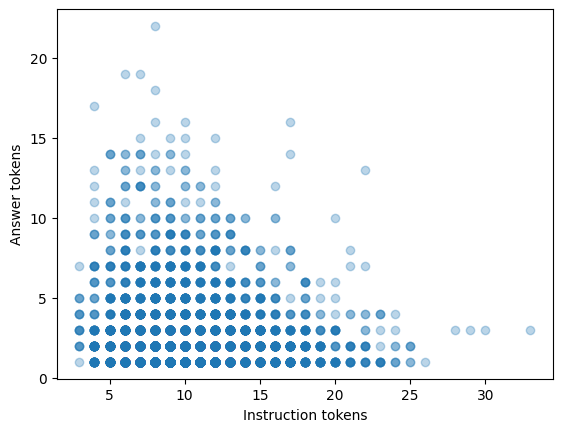

In [ ]:
scatter_plot(tokens_instructions, tokens_answers)

In [ ]:
# 13 question-answer pairs are duplicate
pairs = [(x["instruction"], x["answer"]) for x in test_ds]
duplicate_count = len(pairs) - len(set(pairs))
duplicate_count

13

In [14]:
# remove duplicate question-answer pairs (13)
seen = set()
indices_to_keep = []

for i, example in enumerate(test_ds):
    key = (example["instruction"], example["answer"])
    if key not in seen:
        seen.add(key)
        indices_to_keep.append(i)

test_ds_unique = test_ds.select(indices_to_keep)

print(f"Original size: {len(test_ds)}")
print(f"After deduplication: {len(test_ds_unique)}")

Original size: 5351
After deduplication: 5338


In [ ]:
pairs = [(x["instruction"], x["answer"]) for x in test_ds_unique]
duplicate_count = len(pairs) - len(set(pairs))
duplicate_count

0

### Analysis of uniqueness in answers
Since the answers are short and seem repetitive, we will analyze them in more depth to see if they hold a good uniqueness value

In [ ]:
df = pd.DataFrame(test_ds_unique)
df["answer_tokens"] = df["answer"].apply(lambda x: x.strip().split())
df["answer_len"] = df["answer_tokens"].apply(len)

In [ ]:
# Answers > 1 token have a high uniqueness ratio
uniqueness_stats = (
    df.groupby("answer_len")["answer"]
      .agg(
          total_count="count",
          unique_count=pd.Series.nunique
      )
      .reset_index()
)

uniqueness_stats["uniqueness_ratio"] = (
    uniqueness_stats["unique_count"] / uniqueness_stats["total_count"]
)

uniqueness_stats

,answer_len,total_count,unique_count,uniqueness_ratio
0,1,1943,1226,0.630983
1,2,1569,1285,0.818993
2,3,819,749,0.914530
3,4,359,341,0.949861
4,5,209,193,0.923445
5,6,130,129,0.992308
6,7,105,99,0.942857
7,8,60,55,0.916667
8,9,44,39,0.886364
9,10,34,30,0.882353


In [ ]:
short_df = df[df["answer_len"].isin([1, 2])]

In [ ]:
one_token_answers = df[df["answer_len"] == 1]["answer"]
Counter(one_token_answers).most_common(10)

[('three', 44),
 ('two', 31),
 ('four', 28),
 ('seven', 18),
 ('five', 17),
 ('six', 17),
 ('ten', 15),
 ('eight', 13),
 ('one', 12),
 ('nine', 12)]

In [ ]:
two_token_answers = df[df["answer_len"] == 2]["answer"]
Counter(two_token_answers).most_common(10)

[('peyton manning', 9),
 ('arizona cardinals', 8),
 ('levis stadium', 7),
 ('carolina panthers', 6),
 ('san diego', 6),
 ('george westinghouse', 6),
 ('united states', 6),
 ('denver broncos', 6),
 ('civil disobedience', 5),
 ('thomas edison', 5)]

In [ ]:
# Dominance ratio < 5% signifies high diversity
dominance_1 = dominance_ratio(one_token_answers)
dominance_2 = dominance_ratio(two_token_answers)

dominance_1, dominance_2

(0.022645393721049924, 0.0057361376673040155)

In [ ]:
# Higher entropy = higher lexical diversity
entropy_1 = entropy(one_token_answers)
entropy_2 = entropy(two_token_answers)

entropy_1, entropy_2

(9.75993646788866, 10.174634723990348)

In [ ]:
freqs_1 = sorted(Counter(one_token_answers).values(), reverse=True)
freqs_2 = sorted(Counter(two_token_answers).values(), reverse=True)

freqs_1[:10], freqs_1[-10:]

([44, 31, 28, 18, 17, 17, 15, 13, 12, 12], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
summary = pd.DataFrame({
    "Answer Length": [1, 2],
    "Total Samples": [len(one_token_answers), len(two_token_answers)],
    "Unique Answers": [
        one_token_answers.nunique(),
        two_token_answers.nunique()
    ],
    "Uniqueness Ratio": [
        one_token_answers.nunique() / len(one_token_answers),
        two_token_answers.nunique() / len(two_token_answers)
    ],
    "Dominance Ratio": [dominance_1, dominance_2],
    "Entropy": [entropy_1, entropy_2]
})

summary

,Answer Length,Total Samples,Unique Answers,Uniqueness Ratio,Dominance Ratio,Entropy
0,1,1943,1226,0.630983,0.022645,9.759936
1,2,1569,1285,0.818993,0.005736,10.174635


### Analysis of audio field

In [15]:
# decode audio field now as we will analyze it
test_ds_unique = test_ds_unique.cast_column("context", Audio(decode=True))

In [ ]:
test_ds_unique[0]

{'context': <datasets.features._torchcodec.AudioDecoder at 0x7ecc6df6e300>,
 'instruction': 'What did Luther think was required to stop the violence?',
 'answer': 'personal presence'}

In [16]:
test_ds_unique = test_ds_unique.map(
    lambda x: {"duration_sec": duration(x["context"])}
)

Map:   0%|          | 0/5338 [00:00<?, ? examples/s]

In [ ]:
df_audio = test_ds_unique.to_pandas()

In [ ]:
# Length of audio segments lies between 12 sec to 5 min
# Majority of the audio segments lie around the 60 sec mark
df_audio["duration_sec"].describe()

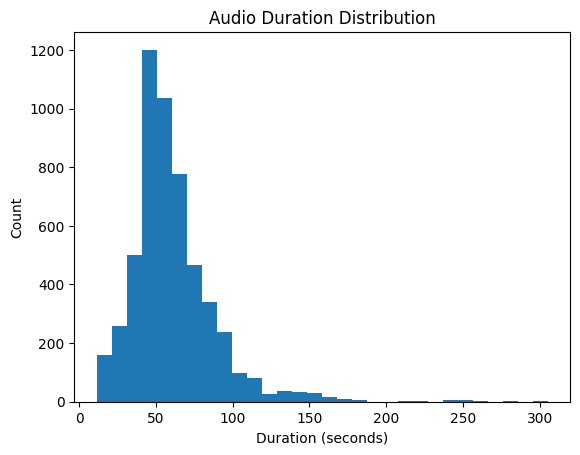

In [ ]:
plt.figure()
plt.hist(df_audio["duration_sec"], bins=30)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Audio Duration Distribution")
plt.show()

In [ ]:
df_audio["duration_bin"] = pd.cut(
    df_audio["duration_sec"],
    bins=[0,5,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,300]
)

df_audio["duration_bin"].value_counts().sort_index()

,count
duration_bin,
"(0, 5]",0
"(5, 10]",0
"(10, 20]",133
"(20, 30]",247
"(30, 40]",422
"(40, 50]",1226
"(50, 60]",1086
"(60, 70]",789
"(70, 80]",498


In [17]:
# For uniformity, budget and to avoid outliers, we'll consider audio <= 60 sec
print(f"Original size: {len(test_ds_unique)}")
test_ds_unique = test_ds_unique.filter(lambda x: x["duration_sec"] <= 60)
print(f"After filtering > 60 sec: {len(test_ds_unique)}")

Original size: 5338


Filter:   0%|          | 0/5338 [00:00<?, ? examples/s]

After filtering > 60 sec: 3114


In [ ]:
test_ds_unique = test_ds_unique.map(
    lambda x: {"sampling_rate": x["context"]["sampling_rate"]}
)

Map:   0%|          | 0/3114 [00:00<?, ? examples/s]

In [ ]:
test_ds_unique = test_ds_unique.map(
    lambda x: {"snr": estimate_snr(x["context"])}
)

Map:   0%|          | 0/3114 [00:00<?, ? examples/s]

In [ ]:
df_audio = test_ds_unique.to_pandas()

In [ ]:
df_audio["duration_sec"].describe()

,duration_sec
count,3114.000000
mean,44.378944
std,10.759667
min,11.568000
25%,39.732000
50%,45.960000
75%,52.464000
max,59.976000


In [ ]:
df_audio["sampling_rate"].describe()

,sampling_rate
count,3114.0
mean,16000.0
std,0.0
min,16000.0
25%,16000.0
50%,16000.0
75%,16000.0
max,16000.0


In [ ]:
# Sampling rate is same and consistent, no need for normalization
df_audio["sampling_rate"].value_counts()

,count
sampling_rate,
16000,3114


In [ ]:
pd.set_option("display.float_format", "{:.20f}".format)

In [ ]:
# SNR values clustered around zero suggest that the chosen estimation method does not offer very good insights
# audio is very clear when studied manually - limited interpretability - need to find a different method to measure SNR if possible
df_audio["snr"].describe()

,snr
count,3114.00000000000000000000
mean,-0.00000016085219556317
std,0.00000074204655220456
min,-0.00000258859745372320
25%,-0.00000077657915653617
50%,-0.00000025885969989758
75%,0.00000051771934295175
max,0.00000258859608948114


In [18]:
# For analyzing the accuracy of memory retention very objectively, we'll drop the outliers and limit the answer entries to less than 10 tokens
def add_answer_len(example):
    return {
        **example,
        "answer_len": len(example["answer"].strip().split())
    }

test_ds_unique = test_ds_unique.map(add_answer_len)
test_ds_unique = test_ds_unique.filter(lambda x: x["answer_len"] < 10)

Map:   0%|          | 0/3114 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3114 [00:00<?, ? examples/s]

In [19]:
len(test_ds_unique)

3056

### Select subset and analyze again

In [20]:
# For budgetary constraints and to avoid dilution of results, we'll limit final subset entries to 1,000
test_ds_v2 = test_ds_unique.shuffle(seed=42).select(range(1000))

In [21]:
len(test_ds_v2)

1000

In [22]:
test_ds_v2.features

{'context': Audio(sampling_rate=None, decode=True, stream_index=None),
 'instruction': Value('string'),
 'answer': Value('string'),
 'duration_sec': Value('float64'),
 'answer_len': Value('int64')}

In [23]:
#Since subset is selected, we'll analyze text fields again to verify that original structure is retained in the subset

In [24]:
tokens_instructions_v2 = [len(x["instruction"].split()) for x in test_ds_v2]
tokens_answers_v2  = [len(x["answer"].split()) for x in test_ds_v2]

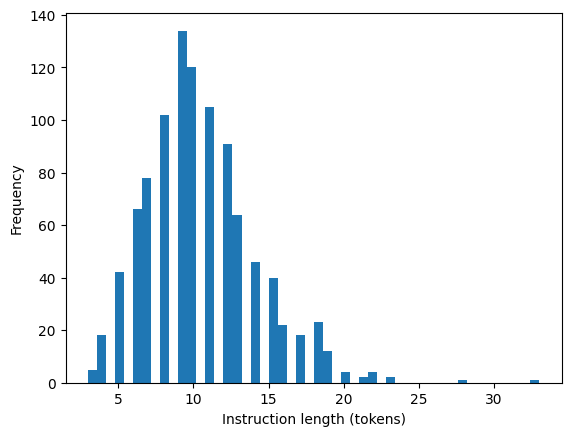

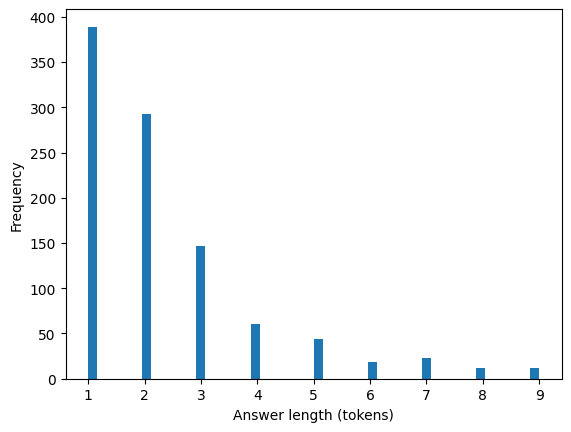

In [26]:
plot_histogram(tokens_instructions_v2, "Instruction length (tokens)")
print()
plot_histogram(tokens_answers_v2, "Answer length (tokens)")

In [27]:
pd.Series(tokens_instructions_v2).describe()

,0
count,1000.000000
mean,10.401000
std,3.661093
min,3.000000
25%,8.000000
50%,10.000000
75%,12.000000
max,33.000000


In [28]:
pd.Series(tokens_answers_v2).describe()

,0
count,1000.000000
mean,2.359000
std,1.717285
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,9.000000


In [29]:
outliers_instructions_v2 = find_outliers(tokens_instructions_v2)
outliers_answers_v2 = find_outliers(tokens_answers_v2)

len(outliers_instructions_v2), len(outliers_answers_v2)

(26, 47)

In [30]:
instructions_v2 = [x["instruction"] for x in test_ds_v2]
Counter(instructions_v2).most_common(20)

[('What does UMC stand for?', 1),
 ('Who tackled Ronnie Hillman for a loss of yardage?', 1),
 ('What can keep an object from moving when it is being pushed on a surface?',
  1),
 ('What type of shadow does the North Pennines cast?', 1),
 ('The largest brand of what store in the UK is located in Kingston Park?', 1),
 ('What do some civil disobedient people feel the need to acknowledge.', 1),
 ('Who does the Presiding Officer submit the final bill to?', 1),
 ("What caused Jacksonville's tourism to become less desirable at the latter half of the 19th century?",
  1),
 ('How many NFL teams have had only one loss by the end of a regular season?',
  1),
 ('How are the pyrenoid and thylakoids arranged?', 1),
 ('what did he do for $2 a day?', 1),
 ('What type of education is sometimes present at religious schools in addition to the secular curriculum?',
  1),
 ('What kind of company is Sky UK Limited?', 1),
 ('Static friction balances what force when there is no movement of an object on a surf

In [31]:
unique_instructions_ratio_v2 = unique_ratio(instructions_v2)
unique_instructions_ratio_v2

1.0

In [32]:
answers_v2 = [x["answer"] for x in test_ds_v2]
Counter(answers_v2).most_common(100)

[('three', 8),
 ('miller', 5),
 ('five', 5),
 ('four', 5),
 ('seven', 4),
 ('two', 4),
 ('gold', 4),
 ('arizona cardinals', 4),
 ('super bowl city', 3),
 ('south', 3),
 ('one', 3),
 ('los angeles', 3),
 ('germany', 3),
 ('singing', 3),
 ('ealy', 3),
 ('united methodist church', 2),
 ('static friction', 2),
 ('ten', 2),
 ('religious', 2),
 ('number one', 2),
 ('time', 2),
 ('eight', 2),
 ('british', 2),
 ('anderson', 2),
 ('new england patriots', 2),
 ('coal', 2),
 ('innate immune system versus the adaptive immune system', 2),
 ('teaching', 2),
 ('john elway', 2),
 ('sidelines', 2),
 ('death wish coffee', 2),
 ('jackson', 2),
 ('riverside', 2),
 ('seizures', 2),
 ('albert einstein', 2),
 ('new york city', 2),
 ('super bowl opening night', 2),
 ('climate fluctuations', 2),
 ('john fox', 2),
 ('teachers colleges', 2),
 ('business', 2),
 ('constitutional impasse', 2),
 ('economic', 2),
 ('the courts of member states', 2),
 ('god', 2),
 ('economist', 2),
 ('general relativity', 2),
 ('april

In [33]:
# there is a significant increase in answer uniqueness
unique_answers_ratio_v2 = unique_ratio(answers_v2)
unique_answers_ratio_v2

0.906

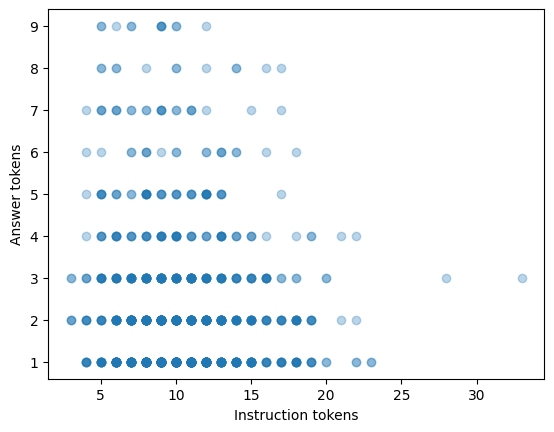

In [34]:
scatter_plot(tokens_instructions_v2, tokens_answers_v2)

### Save selected subset

In [35]:
len(test_ds_v2)

1000

In [36]:
test_ds_v2.features

{'context': Audio(sampling_rate=None, decode=True, stream_index=None),
 'instruction': Value('string'),
 'answer': Value('string'),
 'duration_sec': Value('float64'),
 'answer_len': Value('int64')}

In [37]:
login()

In [39]:
# https://huggingface.co/datasets/byteCode18/spoken-squad-1k-memory-eval

repo_name = "spoken-squad-1k-memory-eval"

test_ds_v2.push_to_hub(
    repo_name,
    private=True
)

Uploading the dataset shards:   0%|          | 0/3 [00:00<?, ? shards/s]

Map:   0%|          | 0/334 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   0%|          |  677kB /  408MB            

CommitInfo(commit_url='https://huggingface.co/datasets/byteCode18/spoken-squad-1k-memory-eval/commit/5d467643e626f09ed819145ca7cf8a21412d9be5', commit_message='Upload dataset', commit_description='', oid='5d467643e626f09ed819145ca7cf8a21412d9be5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/byteCode18/spoken-squad-1k-memory-eval', endpoint='https://huggingface.co', repo_type='dataset', repo_id='byteCode18/spoken-squad-1k-memory-eval'), pr_revision=None, pr_num=None)

In [40]:
#test load dataset: byteCode18/spoken-squad-1k-memory-eval
sub_ds = load_dataset("byteCode18/spoken-squad-1k-memory-eval")

README.md:   0%|          | 0.00/453 [00:00<?, ?B/s]

data/test-00000-of-00003.parquet:   0%|          | 0.00/401M [00:00<?, ?B/s]

data/test-00001-of-00003.parquet:   0%|          | 0.00/400M [00:00<?, ?B/s]

data/test-00002-of-00003.parquet:   0%|          | 0.00/408M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [44]:
len(sub_ds['test'])

1000

In [45]:
sub_ds['test'].features

{'context': Audio(sampling_rate=None, decode=True, stream_index=None),
 'instruction': Value('string'),
 'answer': Value('string'),
 'duration_sec': Value('float64'),
 'answer_len': Value('int64')}